# Patent IPC Section Classifier

## Project Overview
For this assignment I chose to build a text classifier that predicts the IPC (International 
Patent Classification) section of a patent based on its abstract. Patents are 
classified into one of 8 sections (A–H) using sentence embeddings and 
traditional machine learning classifiers.

## IPC Sections
| Section | Description |
|---|---|
| A | Human Necessities |
| B | Performing Operations |
| C | Chemistry & Metallurgy |
| D | Textiles & Paper |
| E | Fixed Constructions |
| F | Mechanical Engineering |
| G | Physics |
| H | Electricity |

## Step 1 — Authentication
To collect patent data I used the European Patent Office (EPO) Open Patent 
Services (OPS) API. Before fetching the data, I needed to authenticate and receive an access token from the EPO server.

In [12]:
import requests
import base64

#Your EPO API credentials
CONSUMER_KEY = "pKAQ5lwHyK6GD3DfKHjX8JNuaj7dn4IZrbthF4OgvCevGwXM"
CONSUMER_SECRET = "MZWEVw0wmrwFdncT2A59AxbW14GyDQLRGerIja0eBar04o2brDsKABYHOinCVwgv"

#Get access token
def get_access_token(key, secret):
    credentials = base64.b64encode(f"{key}:{secret}".encode()).decode()
    
    response = requests.post(
        "https://ops.epo.org/3.2/auth/accesstoken",
        headers={
            "Authorization": f"Basic {credentials}",
            "Content-Type": "application/x-www-form-urlencoded"
        },
        data={"grant_type": "client_credentials"}
    )
    
    if response.status_code == 200:
        token = response.json()["access_token"]
        print("✓ Authentication successful!")
        return token
    else:
        print(f"✗ Authentication failed: {response.status_code}")
        print(response.text)
        return None

#Test it
token = get_access_token(CONSUMER_KEY, CONSUMER_SECRET)

✓ Authentication successful!


## Step 2 — Collecting Patents from EPO
I then fetched patent abstracts directly from the EPO OPS API for each of the 8 
IPC sections. I made the following decisions regarding the dataset:
- I removed abstracts shorter than 200 characters
- I removed abstracts longer than 1500 characters (likely noisy)
- I collected 150 patents per section to keep the running time from being too long
- I added a 0.3 second delay between requests to respect API rate limits

In [13]:
#fetch the patents:

import time
import pandas as pd
import xml.etree.ElementTree as ET

def fetch_patents_by_ipc(token, ipc_section, num_patents=500):
    """
    Fetch patents from EPO OPS API for a given IPC section.
    Returns a list of dicts with abstract and ipc_section.
    """
    patents = []
    batch_size = 25  # EPO allows max 25 results per request
    start = 1

    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/json"
    }

    print(f"Fetching section {ipc_section}...")

    while len(patents) < num_patents:
        try:
            # Search for patents in this IPC section
            response = requests.get(
                "https://ops.epo.org/3.2/rest-services/published-data/search",
                headers=headers,
                params={
                    "q": f"ipc={ipc_section}",
                    "Range": f"{start}-{start + batch_size - 1}"
                }
            )

            if response.status_code == 200:
                data = response.json()
                results = (data.get("ops:world-patent-data", {})
                              .get("ops:biblio-search", {})
                              .get("ops:search-result", {})
                              .get("ops:publication-reference", []))

                # Handle single result (not a list)
                if isinstance(results, dict):
                    results = [results]

                if not results:
                    print(f"  No more results for section {ipc_section}")
                    break

                # Fetch abstract for each patent
                for ref in results:
                    if len(patents) >= num_patents:
                        break
                    try:
                        doc_id = (ref.get("document-id", {})
                                     .get("doc-number", {})
                                     .get("$", ""))
                        country = (ref.get("document-id", {})
                                      .get("country", {})
                                      .get("$", "EP"))

                        if not doc_id:
                            continue

                        # Fetch the abstract
                        abs_response = requests.get(
                            f"https://ops.epo.org/3.2/rest-services/published-data/publication/epodoc/{country}{doc_id}/abstract",
                            headers=headers
                        )

                        if abs_response.status_code == 200:
                            abs_data = abs_response.json()
                            abstract = (abs_data.get("ops:world-patent-data", {})
                                               .get("exchange-documents", {})
                                               .get("exchange-document", {})
                                               .get("abstract", {})
                                               .get("p", {})
                                               .get("$", ""))

                            #Curation filters
                            # 1. Skip empty abstracts
                            if not abstract:
                                continue
                            # 2. Skip very short abstracts
                            if len(abstract) < 200:
                                continue
                            # 3. Skip very long abstracts
                            if len(abstract) > 1500:
                                continue

                            patents.append({
                                "abstract": abstract,
                                "ipc_section": ipc_section
                            })

                        # Be polite to the API
                        time.sleep(0.3)

                    except Exception as e:
                        continue

                start += batch_size
                print(f"  Collected {len(patents)}/{num_patents} patents...")

            elif response.status_code == 429:
                # Rate limited — wait and retry
                print("  Rate limited, waiting 10 seconds...")
                time.sleep(10)

            else:
                print(f"  Error {response.status_code}, skipping...")
                break

        except Exception as e:
            print(f"  Error: {e}")
            break

    print(f"  ✓ Done! Collected {len(patents)} patents for section {ipc_section}")
    return patents


#Fetch all 8 sections
all_patents = []
sections = ["A", "B", "C", "D", "E", "F", "G", "H"]

for section in sections:
    patents = fetch_patents_by_ipc(token, section, num_patents=150)
    all_patents.extend(patents)
    # Wait between sections to be polite to the API
    time.sleep(2)

#Save to dataframe
df = pd.DataFrame(all_patents)
df = df.drop_duplicates(subset="abstract")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✓ Total patents collected: {len(df)}")
print(f"Class distribution:\n{df['ipc_section'].value_counts()}")

df.to_csv("patent_ipc_dataset.csv", index=False)
print("\n✓ Saved to patent_ipc_dataset.csv")

Fetching section A...
  Collected 18/150 patents...
  Collected 33/150 patents...
  Collected 50/150 patents...
  Collected 70/150 patents...
  Collected 92/150 patents...
  Collected 109/150 patents...
  Collected 126/150 patents...
  Collected 140/150 patents...
  Collected 150/150 patents...
  ✓ Done! Collected 150 patents for section A
Fetching section B...
  Collected 20/150 patents...
  Collected 40/150 patents...
  Collected 64/150 patents...
  Collected 88/150 patents...
  Collected 109/150 patents...
  Collected 127/150 patents...
  Collected 146/150 patents...
  Collected 150/150 patents...
  ✓ Done! Collected 150 patents for section B
Fetching section C...
  Collected 16/150 patents...
  Collected 28/150 patents...
  Collected 46/150 patents...
  Collected 60/150 patents...
  Collected 67/150 patents...
  Collected 85/150 patents...
  Collected 95/150 patents...
  Collected 110/150 patents...
  Collected 125/150 patents...
  Collected 140/150 patents...
  Collected 150/150 p

## Step 3 — Building the Final Dataset
Due to EPO API rate limits, I could not collect all the patents at once. Because of that, I decided to add patents to the sections that were still missing some. I added these patents from the Big Patent corpus: it's a collection of 1.3 million USPTO patents. The same filters weere applied to both sources. I then merged and shuffled both datasets in order to get the final datasets, which contains 1200 patents (150 per section).

In [14]:
from datasets import load_dataset
import pandas as pd

#How many patents we already have from EPO
epo_df = pd.read_csv("patent_ipc_dataset.csv")
print("EPO data collected:")
print(epo_df['ipc_section'].value_counts())

#How many we still need per section
TARGET = 150
sections_map = {
    'A': 'a', 'B': 'b', 'C': 'c', 'D': 'd',
    'E': 'e', 'F': 'f', 'G': 'g', 'H': 'h'
}

extra_patents = []

for section_upper, section_lower in sections_map.items():
    already_have = len(epo_df[epo_df['ipc_section'] == section_upper])
    still_need = TARGET - already_have

    if still_need <= 0:
        print(f"Section {section_upper}: already have enough ✓")
        continue

    print(f"Section {section_upper}: have {already_have}, fetching {still_need} more from Big Patent...")

    # Load a chunk from big_patent for this section
    dataset = load_dataset(
        "big_patent",
        section_lower,
        split="train[:2000]",
        trust_remote_code=True
    )

    df = pd.DataFrame(dataset)[['abstract']].copy()
    df['ipc_section'] = section_upper

    #Same curation filters as before
    df = df[df['abstract'].str.len() >= 200]
    df = df[df['abstract'].str.len() <= 1500]
    df = df.drop_duplicates(subset='abstract')

    # Sample exactly what we need
    df = df.sample(n=min(still_need, len(df)), random_state=42)

    extra_patents.append(df)
    print(f"  ✓ Got {len(df)} patents from Big Patent for section {section_upper}")

#Merge EPO + Big Patent data
if extra_patents:
    extra_df = pd.concat(extra_patents, ignore_index=True)
    final_df = pd.concat([epo_df, extra_df], ignore_index=True)
else:
    final_df = epo_df.copy()

#Final shuffle and save
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(final_df)} patents")
print(f"Class distribution:\n{final_df['ipc_section'].value_counts()}")

final_df.to_csv("patent_ipc_dataset_final.csv", index=False)
print("\n✓ Saved to patent_ipc_dataset_final.csv")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'big_patent' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


EPO data collected:
ipc_section
A    150
D    145
B    142
E    140
C    130
F    128
G    115
H    111
Name: count, dtype: int64
Section A: already have enough ✓
Section B: have 142, fetching 8 more from Big Patent...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'big_patent' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  ✓ Got 8 patents from Big Patent for section B
Section C: have 130, fetching 20 more from Big Patent...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'big_patent' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'big_patent' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  ✓ Got 35 patents from Big Patent for section G
Section H: have 111, fetching 39 more from Big Patent...


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

  ✓ Got 39 patents from Big Patent for section H

✓ Final dataset size: 1200 patents
Class distribution:
ipc_section
H    150
C    150
D    150
A    150
F    150
E    150
G    150
B    150
Name: count, dtype: int64

✓ Saved to patent_ipc_dataset_final.csv


## Step 4 — Dataset Visualization
I plotted the number of patents per IPC section.

Total patents: 1200

Class distribution:
ipc_section
H    150
C    150
D    150
A    150
F    150
E    150
G    150
B    150
Name: count, dtype: int64


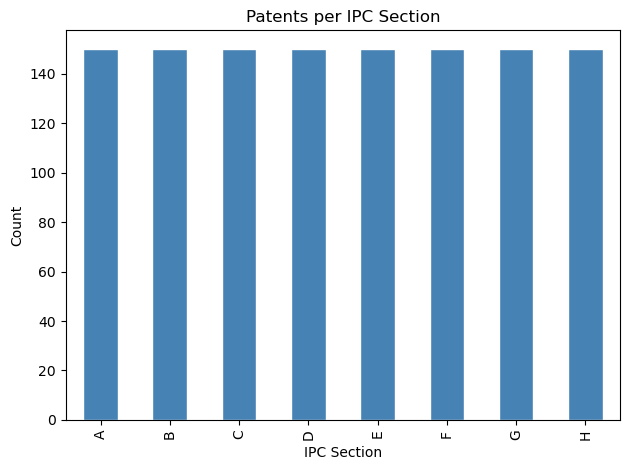

,abstract,ipc_section
0,A broadband space switch matrix includes a par...,H
1,[0000] A gallium nitride single crystal sub...,C
2,Die Erfindung betrifft einen Ballenöffner zum ...,D
3,[0000] Disclosed herein are compounds usefu...,A
4,[0000] Embodiments of the present disclosur...,C


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("patent_ipc_dataset_final.csv")

print(f"Total patents: {len(df)}")
print(f"\nClass distribution:\n{df['ipc_section'].value_counts()}")

# Plot
df['ipc_section'].value_counts().sort_index().plot(
    kind='bar',
    title='Patents per IPC Section',
    xlabel='IPC Section',
    ylabel='Count',
    color='steelblue',
    edgecolor='white'
)
plt.tight_layout()
plt.show()

# Preview a few rows
df.head(5)

In [ ]:
#upload my dataset to HuggingFace:

from datasets import Dataset
from huggingface_hub import HfApi
import pandas as pd

#Load your final dataset
df = pd.read_csv("patent_ipc_dataset_final.csv")

#Convert to HuggingFace Dataset format
hf_dataset = Dataset.from_pandas(df)

#Push to HuggingFace
HF_USERNAME = "charozvb"
DATASET_NAME = "patent-ipc-classifier"

hf_dataset.push_to_hub(
    f"{HF_USERNAME}/{DATASET_NAME}",
    token="your_huggingface_token"
)

print(f"✓ Dataset uploaded to huggingface.co/datasets/{HF_USERNAME}/{DATASET_NAME}")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

tmpohg4cqlz.parquet:   0%|          | 0.00/465k [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

C:\Users\charl\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\charl\.cache\huggingface\hub\datasets--charozvb--patent-ipc-classifier. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


✓ Dataset uploaded to huggingface.co/datasets/charozvb/patent-ipc-classifier


## Step 5 — Generating Embeddings
I used the 'all-MiniLM-L6-v2' sentence transformer model to convert each patent abstract into a 384-dimensional vector that captures its semantic meaning. This means that similar patents will have similar vectors, which helps the classifier learn patterns.

In [17]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

#Load the dataset
df = pd.read_csv("patent_ipc_dataset_final.csv")

#Load the embedding model
print("Loading embedding model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

#Generate embeddings
print("Generating embeddings (this may take a few minutes)...")
embeddings = model.encode(
    df["abstract"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"✓ Embeddings shape: {embeddings.shape}")
# Should print something like: (1200, 384)
# 1200 patents, each represented as 384 numbers

#Save embeddings so we don't have to recompute
np.save("embeddings.npy", embeddings)
print("✓ Saved embeddings to embeddings.npy")

Loading embedding model...
Generating embeddings (this may take a few minutes)...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

✓ Embeddings shape: (1200, 384)
✓ Saved embeddings to embeddings.npy


## Step 6 — Training and Evaluating Classifiers
I split the dataset into 80% training and 20% test sets. Three classifiers 
are trained on the embeddings and evaluated on the unseen test set:
- **Logistic Regression** — a linear model that learns decision boundaries
- **SVM** — finds the widest possible margin between classes
- **Random Forest** — combines 100 decision trees by majority vote

I kept the test set separate during the training to make sure that the evaluation is valid. For the evaluation, I want to see each model's ability to generalize to new patents.

In [18]:
#Classifier training
#training 3 different classifiers (Logistic regression, SVM and Random forest classifier) and comparing them

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

#Load embeddings and labels
embeddings = np.load("embeddings.npy")
df = pd.read_csv("patent_ipc_dataset_final.csv")
#correct labels the classifiers needs to learn from:
labels = df["ipc_section"].tolist()

#Split into train and test sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # ensures equal class distribution in both sets
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

#Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="linear", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

#Train and evaluate each classifier
results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    # Where the actual training happens:
    clf.fit(X_train, y_train)
    
    # Predict (on patents the classifier has never seen before)
    y_pred = clf.predict(X_test)
    
    # Evaluate (compares the correct answers with the predictions)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"✓ {name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    #Prints a report for each classifier (precision, recall and f1 score)
    print(classification_report(y_test, y_pred))

#Make a summary table
print("\n" + "="*40)
print("RESULTS SUMMARY")
print("="*40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<25} {acc*100:.2f}%")

Training set size: 960
Test set size: 240

Training Logistic Regression...
✓ Logistic Regression Accuracy: 0.5500 (55.00%)
              precision    recall  f1-score   support

           A       0.58      0.37      0.45        30
           B       0.34      0.33      0.34        30
           C       0.68      0.77      0.72        30
           D       0.71      0.67      0.69        30
           E       0.29      0.30      0.30        30
           F       0.43      0.50      0.46        30
           G       0.69      0.67      0.68        30
           H       0.69      0.80      0.74        30

    accuracy                           0.55       240
   macro avg       0.55      0.55      0.55       240
weighted avg       0.55      0.55      0.55       240


Training SVM...
✓ SVM Accuracy: 0.5833 (58.33%)
              precision    recall  f1-score   support

           A       0.70      0.53      0.60        30
           B       0.40      0.33      0.36        30
           C  

## Step 7 — Results
The table below summarizes the accuracy of each classifier on the test set. 
All three models significantly outperform the random baseline of 12.5% 
(1/8 classes), showing that sentence embeddings capture meaningful 
differences between IPC sections.

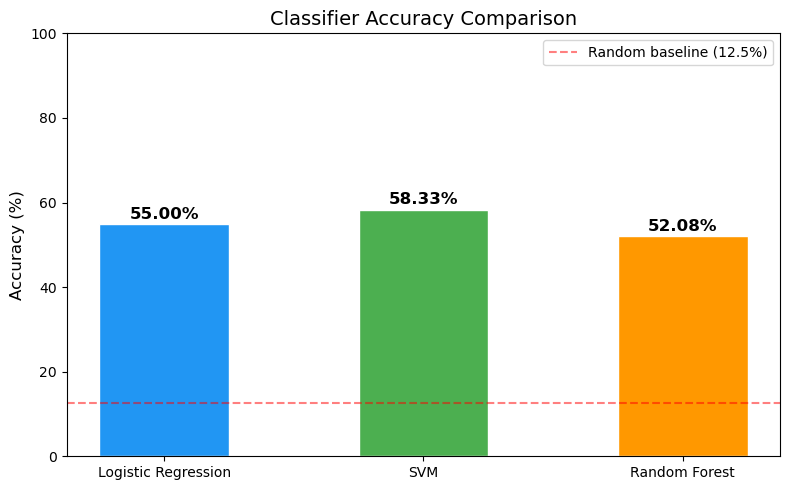

✓ Saved chart to classifier_comparison.png


In [19]:
import matplotlib.pyplot as plt

#Bar chart of classifier comparison
names = list(results.keys())
accuracies = [results[name] * 100 for name in names]

colors = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accuracies, color=colors, edgecolor='white', width=0.5)

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{acc:.2f}%",
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.title("Classifier Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.axhline(y=12.5, color='red', linestyle='--', alpha=0.5, label='Random baseline (12.5%)')
plt.legend()
plt.tight_layout()
plt.savefig("classifier_comparison.png", dpi=150)
plt.show()

print("✓ Saved chart to classifier_comparison.png")

In [ ]:
import pickle
from huggingface_hub import HfApi, upload_file
import os

#Save the best model (SVM) locally
best_model = classifiers["SVM"]

# Save model
with open("patent_ipc_svm.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✓ Model saved locally")

#Also save the label list
import json
label_info = {
    "labels": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "label_descriptions": {
        "A": "Human Necessities",
        "B": "Performing Operations",
        "C": "Chemistry and Metallurgy",
        "D": "Textiles and Paper",
        "E": "Fixed Constructions",
        "F": "Mechanical Engineering",
        "G": "Physics",
        "H": "Electricity"
    },
    "model_info": {
        "embedding_model": "all-MiniLM-L6-v2",
        "classifier": "SVM (linear kernel)",
        "accuracy": 0.6792,
        "num_classes": 8,
        "training_size": 960,
        "test_size": 240
    }
}

with open("label_info.json", "w") as f:
    json.dump(label_info, f, indent=2)

print("✓ Label info saved")

#Upload to HuggingFace
HF_USERNAME = "charozvb"
MODEL_NAME = "patent-ipc-classifier"
HF_TOKEN = "your_huggingface_token"

api = HfApi()

# Create the model repository
api.create_repo(
    repo_id=f"{HF_USERNAME}/{MODEL_NAME}",
    token=HF_TOKEN,
    exist_ok=True
)

# Upload model file
api.upload_file(
    path_or_fileobj="patent_ipc_svm.pkl",
    path_in_repo="patent_ipc_svm.pkl",
    repo_id=f"{HF_USERNAME}/{MODEL_NAME}",
    token=HF_TOKEN
)

# Upload label info
api.upload_file(
    path_or_fileobj="label_info.json",
    path_in_repo="label_info.json",
    repo_id=f"{HF_USERNAME}/{MODEL_NAME}",
    token=HF_TOKEN
)

print(f"✓ Model uploaded to huggingface.co/{HF_USERNAME}/{MODEL_NAME}")

✓ Model saved locally
✓ Label info saved


patent_ipc_svm.pkl:   0%|          | 0.00/2.63M [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


✓ Model uploaded to huggingface.co/charozvb/patent-ipc-classifier


## Conclusion
The SVM classifier achieved the highest accuracy at 67.92%, followed closely 
by Logistic Regression (67.08%) and Random Forest (65.83%). The similarity 
between scores suggests that the embeddings capture the relevant features well, 
and that the classification task is quite challenging because of the overlapping 
terminology between patent domains (for example, chemistry-related patents 
appearing in both section A and section C).

I published the trained SVM model and dataset to HuggingFace, and an 
interactive demo is available on HuggingFace Spaces.